# **Task 1: Data Loading**

In [11]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("/content/PRSA_Data_Aotizhongxin_20130301-20170228.csv")

In [3]:
df.head(10)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
5,6,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin
6,7,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin
7,8,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin
8,9,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin
9,10,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin


In [4]:
df.shape

(35064, 18)

In [5]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [6]:
df.isna().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,925
PM10,718
SO2,935
NO2,1023
CO,1776


# **Task 2: Data Cleaning & Preparation**

In [7]:
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df.drop(columns=["year", "month", "day", "hour"], inplace=True)

In [8]:
df = df.sort_values("datetime")
df = df.reset_index(drop=True)

In [9]:
df = df.fillna(method="ffill")

/tmp/ipython-input-567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].astype(float)

# **Task 3: Exploratory Data Analysis (EDA)**

In [15]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']
df[pollutants].describe()

,PM2.5,PM10,SO2,NO2,CO,O3
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,83.163652,110.733262,17.573220,59.290826,1267.071954,55.184512
std,82.290700,95.375762,22.819302,37.007696,1242.121599,57.582259
min,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200
25%,22.000000,38.000000,3.000000,30.000000,500.000000,7.000000
50%,60.000000,88.000000,9.000000,54.000000,900.000000,41.000000
75%,114.000000,157.000000,22.000000,81.000000,1600.000000,82.000000
max,898.000000,984.000000,341.000000,290.000000,10000.000000,423.000000


In [14]:
df["month"] = df["datetime"].dt.month
monthly_pm25 = df.groupby("month")["PM2.5"].mean()
print(monthly_pm25)

month
1      92.379402
2      87.206490
3     100.846169
4      79.484549
5      67.500202
6      71.513889
7      75.051411
8      56.249328
9      64.382743
10     98.084677
11     98.468611
12    106.548387
Name: PM2.5, dtype: float64


In [16]:
station_avg = df.groupby("station")["PM2.5"].mean()
print(station_avg.sort_values(ascending=False))

station
Aotizhongxin    83.163652
Name: PM2.5, dtype: float64


In [17]:
df[["WSPM", "PM2.5"]].corr()

,WSPM,PM2.5
WSPM,1.00000,-0.27357
PM2.5,-0.27357,1.00000


# **Task 4: Data Visualization**

In [18]:
import matplotlib.pyplot as plt

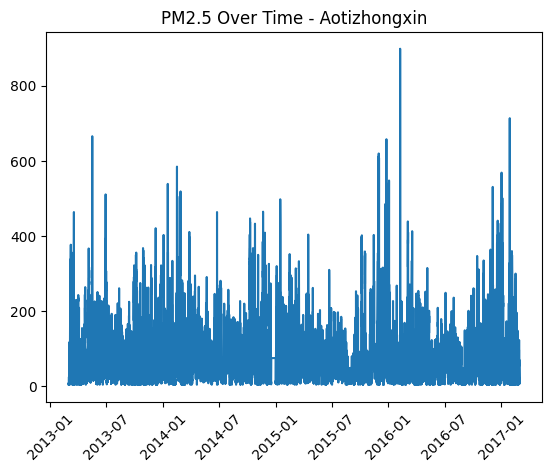

In [19]:
station_name = df["station"].unique()[0]
station_df = df[df["station"] == station_name]
plt.figure()
plt.plot(station_df["datetime"], station_df["PM2.5"])
plt.title(f"PM2.5 Over Time - {station_name}")
plt.xticks(rotation=45)
plt.show()

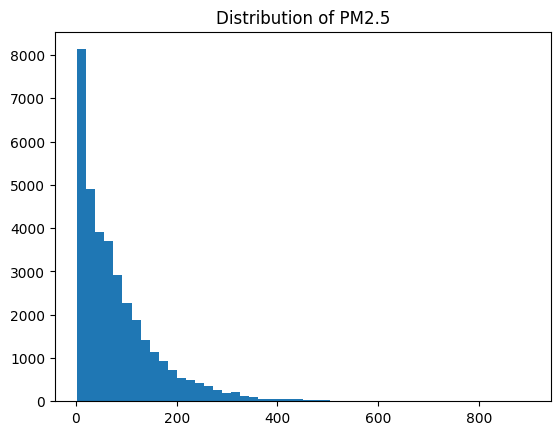

In [20]:
plt.figure()
plt.hist(df["PM2.5"], bins=50)
plt.title("Distribution of PM2.5")
plt.show()

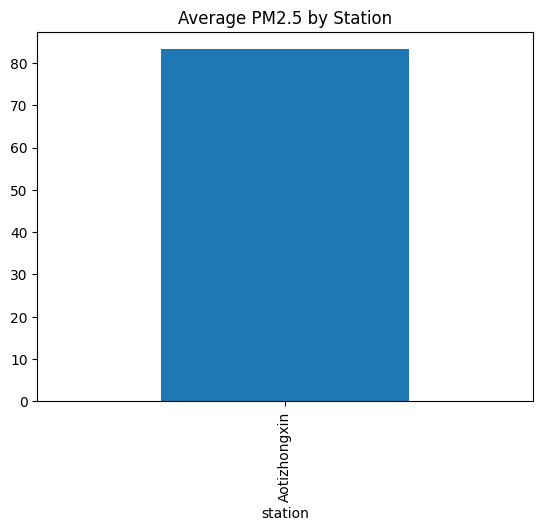

In [21]:
plt.figure()
station_avg.plot(kind="bar")
plt.title("Average PM2.5 by Station")
plt.show()

# **Task 5: Feature Engineering**

In [22]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

In [24]:
df["pollution_load"] = (df["PM2.5"] + df["PM10"] + df["NO2"] + df["SO2"] + df["O3"])

In [25]:
df = pd.get_dummies(df, columns=["wd"], drop_first=True)

# **Task 7: Train–Test Split**

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
features = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM", "pollution_load"]
X = df[features]
y = df["PM2.5"]

In [28]:
split_index = int(len(df) * 0.8)

In [29]:
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# **Task 8: Regression Modeling**

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr

LinearRegression()

In [33]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf

RandomForestRegressor()

In [32]:
def evaluate(y_true, y_pred):
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))
print("Linear Regression Performance")
evaluate(y_test, y_pred_lr)
print("Random Forest Performance")
evaluate(y_test, y_pred_rf)

Linear Regression Performance
MAE: 15.212806247627023
MSE: 417.7263607981763
R2: 0.940256659226633
Random Forest Performance
MAE: 12.408888492799088
MSE: 308.0388341455868
R2: 0.9559441999192339
